# **Data Exploration**

## *Thông tin về dataset*

- Mô tả các yếu tố về khả năng rời đi của một người dùng đối với dịch vụ tín dụng (thẻ ghi nợ) của một ngân hàng nhằm giúp ngân hàng có thể sớm dự đoán và chuẩn bị cho họ một dịch vụ tốt hơn

- Nguồn Kaggle: https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers

## *Chuẩn bị môi trường*

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from IPython.display import display, Markdown, HTML

## *Tải và tóm tắt dữ liệu*

In [3]:
data = np.genfromtxt(
    '../data/raw/BankChurners.csv',
    delimiter=',',          
    dtype=None,            
    encoding='utf-8',       
    names=True             
)

# Xử lý thông tin thống kê
num_samples = data.shape[0]
feature_names = data.dtype.names
num_features = len(feature_names)

# Tạo nội dung Markdown
md_content = f"""
### DATASET SUMMARY
---
- **Số lượng mẫu:** `{num_samples:,}`
- **Số lượng features:** `{num_features}`

<br>

### CHI TIẾT CÁC ĐẶC TRƯNG (FEATURES)
| ID | Tên đặc trưng | Kiểu dữ liệu (Dtype) |
|:---|:---|:---|
"""

for i, name in enumerate(feature_names):
    dtype_val = data.dtype[name]    
    md_content += f"| {i} | **{name}** | `{dtype_val}` |\n"

display(Markdown(md_content))


### DATASET SUMMARY
---
- **Số lượng mẫu:** `10,127`
- **Số lượng features:** `23`

<br>

### CHI TIẾT CÁC ĐẶC TRƯNG (FEATURES)
| ID | Tên đặc trưng | Kiểu dữ liệu (Dtype) |
|:---|:---|:---|
| 0 | **CLIENTNUM** | `int64` |
| 1 | **Attrition_Flag** | `<U19` |
| 2 | **Customer_Age** | `int64` |
| 3 | **Gender** | `<U3` |
| 4 | **Dependent_count** | `int64` |
| 5 | **Education_Level** | `<U15` |
| 6 | **Marital_Status** | `<U10` |
| 7 | **Income_Category** | `<U16` |
| 8 | **Card_Category** | `<U10` |
| 9 | **Months_on_book** | `int64` |
| 10 | **Total_Relationship_Count** | `int64` |
| 11 | **Months_Inactive_12_mon** | `int64` |
| 12 | **Contacts_Count_12_mon** | `int64` |
| 13 | **Credit_Limit** | `float64` |
| 14 | **Total_Revolving_Bal** | `int64` |
| 15 | **Avg_Open_To_Buy** | `float64` |
| 16 | **Total_Amt_Chng_Q4_Q1** | `float64` |
| 17 | **Total_Trans_Amt** | `int64` |
| 18 | **Total_Trans_Ct** | `int64` |
| 19 | **Total_Ct_Chng_Q4_Q1** | `float64` |
| 20 | **Avg_Utilization_Ratio** | `float64` |
| 21 | **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1** | `float64` |
| 22 | **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2** | `float64` |


## *Phân loại dữ liệu dạng numeric và categorical*

In [4]:
numeric_fields = []
categorical_fields = []

for name in data.dtype.names:
    if np.issubdtype(data.dtype[name], np.number):
        numeric_fields.append(name)
    else:
        categorical_fields.append(name)

def format_list(features):
    if not features: return "_Không có_"
    return ", ".join([f"`{f}`" for f in features])

markdown_report = f"""
### PHÂN LOẠI LOẠI DỮ LIỆU (FEATURE TYPES)
---

#### NUMERIC FEATURES
* **Tổng số lượng:** {len(numeric_fields)}
* **Danh sách:** {format_list(numeric_fields)}

<br>

#### CATEGORICAL FEATURES
* **Tổng số lượng:** {len(categorical_fields)}
* **Danh sách:** {format_list(categorical_fields)}
"""

display(Markdown(markdown_report))


### PHÂN LOẠI LOẠI DỮ LIỆU (FEATURE TYPES)
---

#### NUMERIC FEATURES
* **Tổng số lượng:** 17
* **Danh sách:** `CLIENTNUM`, `Customer_Age`, `Dependent_count`, `Months_on_book`, `Total_Relationship_Count`, `Months_Inactive_12_mon`, `Contacts_Count_12_mon`, `Credit_Limit`, `Total_Revolving_Bal`, `Avg_Open_To_Buy`, `Total_Amt_Chng_Q4_Q1`, `Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Ct_Chng_Q4_Q1`, `Avg_Utilization_Ratio`, `Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1`, `Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2`

<br>

#### CATEGORICAL FEATURES
* **Tổng số lượng:** 6
* **Danh sách:** `Attrition_Flag`, `Gender`, `Education_Level`, `Marital_Status`, `Income_Category`, `Card_Category`


- Vì tác giả của dataset khuyên rằng nên bỏ 2 cột cuối là 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2' nên ta sẽ loại bỏ chúng trong các feature là numeric

- Ngoài ra cột CLIENTNUM là id của từng user nên sẽ không mang giá trị trong việc phân tích nên ta cũng sẽ loại bỏ chúng

In [ ]:
numeric_fields = numeric_fields[1:-2]  # Loại bỏ 2 cột cuối theo yêu cầu của tác giả dataset và cột ID của người dùng
print(", ".join(numeric_fields))

Customer_Age, Dependent_count, Months_on_book, Total_Relationship_Count, Months_Inactive_12_mon, Contacts_Count_12_mon, Credit_Limit, Total_Revolving_Bal, Avg_Open_To_Buy, Total_Amt_Chng_Q4_Q1, Total_Trans_Amt, Total_Trans_Ct, Total_Ct_Chng_Q4_Q1, Avg_Utilization_Ratio


## **Thống kê mô tả của dữ liệu:**

### *Thống kê mô tả của dữ liệu numeric*

In [6]:
md_stats = """
### THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)
| Feature Name | Mean (TB) | Std (Độ lệch) | Median (Trung vị) | Min | Max |
| :--- | ---: | ---: | ---: | ---: | ---: |
"""

for col in numeric_fields:
    values = data[col]
    
    # Lọc bỏ NaN
    clean = values[~np.isnan(values)]
    
    # Xử lý trường hợp cột toàn NaN
    if clean.size == 0:
        md_stats += f"| **{col}** | - | - | (All NaN) | - | - |\n"
        continue
        
    # Tính toán các chỉ số
    mean_val = np.mean(clean)
    std_val = np.std(clean)
    median_val = np.median(clean)
    min_val = np.min(clean)
    max_val = np.max(clean)
    
    md_stats += (
        f"| **{col}** "
        f"| {mean_val:,.2f} "
        f"| {std_val:,.2f} "
        f"| {median_val:,.2f} "
        f"| {min_val:,.2f} "
        f"| {max_val:,.2f} |\n"
    )

display(Markdown(md_stats))


### THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)
| Feature Name | Mean (TB) | Std (Độ lệch) | Median (Trung vị) | Min | Max |
| :--- | ---: | ---: | ---: | ---: | ---: |
| **Customer_Age** | 46.33 | 8.02 | 46.00 | 26.00 | 73.00 |
| **Dependent_count** | 2.35 | 1.30 | 2.00 | 0.00 | 5.00 |
| **Months_on_book** | 35.93 | 7.99 | 36.00 | 13.00 | 56.00 |
| **Total_Relationship_Count** | 3.81 | 1.55 | 4.00 | 1.00 | 6.00 |
| **Months_Inactive_12_mon** | 2.34 | 1.01 | 2.00 | 0.00 | 6.00 |
| **Contacts_Count_12_mon** | 2.46 | 1.11 | 2.00 | 0.00 | 6.00 |
| **Credit_Limit** | 8,631.95 | 9,088.33 | 4,549.00 | 1,438.30 | 34,516.00 |
| **Total_Revolving_Bal** | 1,162.81 | 814.95 | 1,276.00 | 0.00 | 2,517.00 |
| **Avg_Open_To_Buy** | 7,469.14 | 9,090.24 | 3,474.00 | 3.00 | 34,516.00 |
| **Total_Amt_Chng_Q4_Q1** | 0.76 | 0.22 | 0.74 | 0.00 | 3.40 |
| **Total_Trans_Amt** | 4,404.09 | 3,396.96 | 3,899.00 | 510.00 | 18,484.00 |
| **Total_Trans_Ct** | 64.86 | 23.47 | 67.00 | 10.00 | 139.00 |
| **Total_Ct_Chng_Q4_Q1** | 0.71 | 0.24 | 0.70 | 0.00 | 3.71 |
| **Avg_Utilization_Ratio** | 0.27 | 0.28 | 0.18 | 0.00 | 1.00 |


### *Thống kê phân phối các giá trị duy nhất của dữ liệu categorical*

In [9]:
html_report = """
<h3 style="color: #2c3e50;"> THỐNG KÊ PHÂN PHỐI BIẾN PHÂN LOẠI</h3>
<hr style="border: 1px solid #eee;">
"""

for col in categorical_fields:
    col_data = data[col]
    values, counts = np.unique(col_data, return_counts=True)
    total = len(col_data)
    
    # Sắp xếp giảm dần theo số lượng
    sorted_indices = np.argsort(-counts) 
    values = values[sorted_indices]
    counts = counts[sorted_indices]
    
    html_report += f"""
    <div style="margin-bottom: 20px;">
        <h4 style="margin: 10px 0;"> Feature: <b>{col}</b> <span style="font-size: 0.8em; color: #7f8c8d;">({len(values)} unique values)</span></h4>
        <table style="width: 100%; border-collapse: collapse; font-family: sans-serif;">
            <thead style="background-color: #f8f9fa;">
                <tr style="border-bottom: 2px solid #ddd; text-align: left;">
                    <th style="padding: 8px; width: 30%;">Value</th>
                    <th style="padding: 8px; width: 15%; text-align: right;">Count</th>
                    <th style="padding: 8px; width: 15%; text-align: right;">Percent</th>
                    <th style="padding: 8px; width: 40%;">Distribution</th>
                </tr>
            </thead>
            <tbody>
    """
    
    for v, c in zip(values, counts):
        pct = (c / total) * 100
        val_str = str(v)
        
        bar_html = f"""
        <div style="background-color: #e9ecef; width: 100%; border-radius: 4px; overflow: hidden;">
            <div style="width: {pct}%; background-color: #3498db; height: 12px;"></div>
        </div>
        """
        
        html_report += f"""
            <tr style="border-bottom: 1px solid #eee;">
                <td style="padding: 6px 8px;"><code>{val_str}</code></td>
                <td style="padding: 6px 8px; text-align: right;"><b>{c:,}</b></td>
                <td style="padding: 6px 8px; text-align: right;">{pct:.2f}%</td>
                <td style="padding: 6px 8px; vertical-align: middle;">{bar_html}</td>
            </tr>
        """
        
    html_report += "</tbody></table></div>"

display(HTML(html_report))

Value,Count,Percent,Distribution
"""Existing Customer""","8,500",83.93%,
"""Attrited Customer""","1,627",16.07%,
Value,Count,Percent,Distribution
"""F""","5,358",52.91%,
"""M""","4,769",47.09%,
Value,Count,Percent,Distribution
"""Graduate""","3,128",30.89%,
"""High School""","2,013",19.88%,
"""Unknown""","1,519",15.00%,
"""Uneducated""","1,487",14.68%,


## **Trực quan hoá phân phối của dữ liệu**

### *Trực quan hoá phân phối dữ liệu numeric*

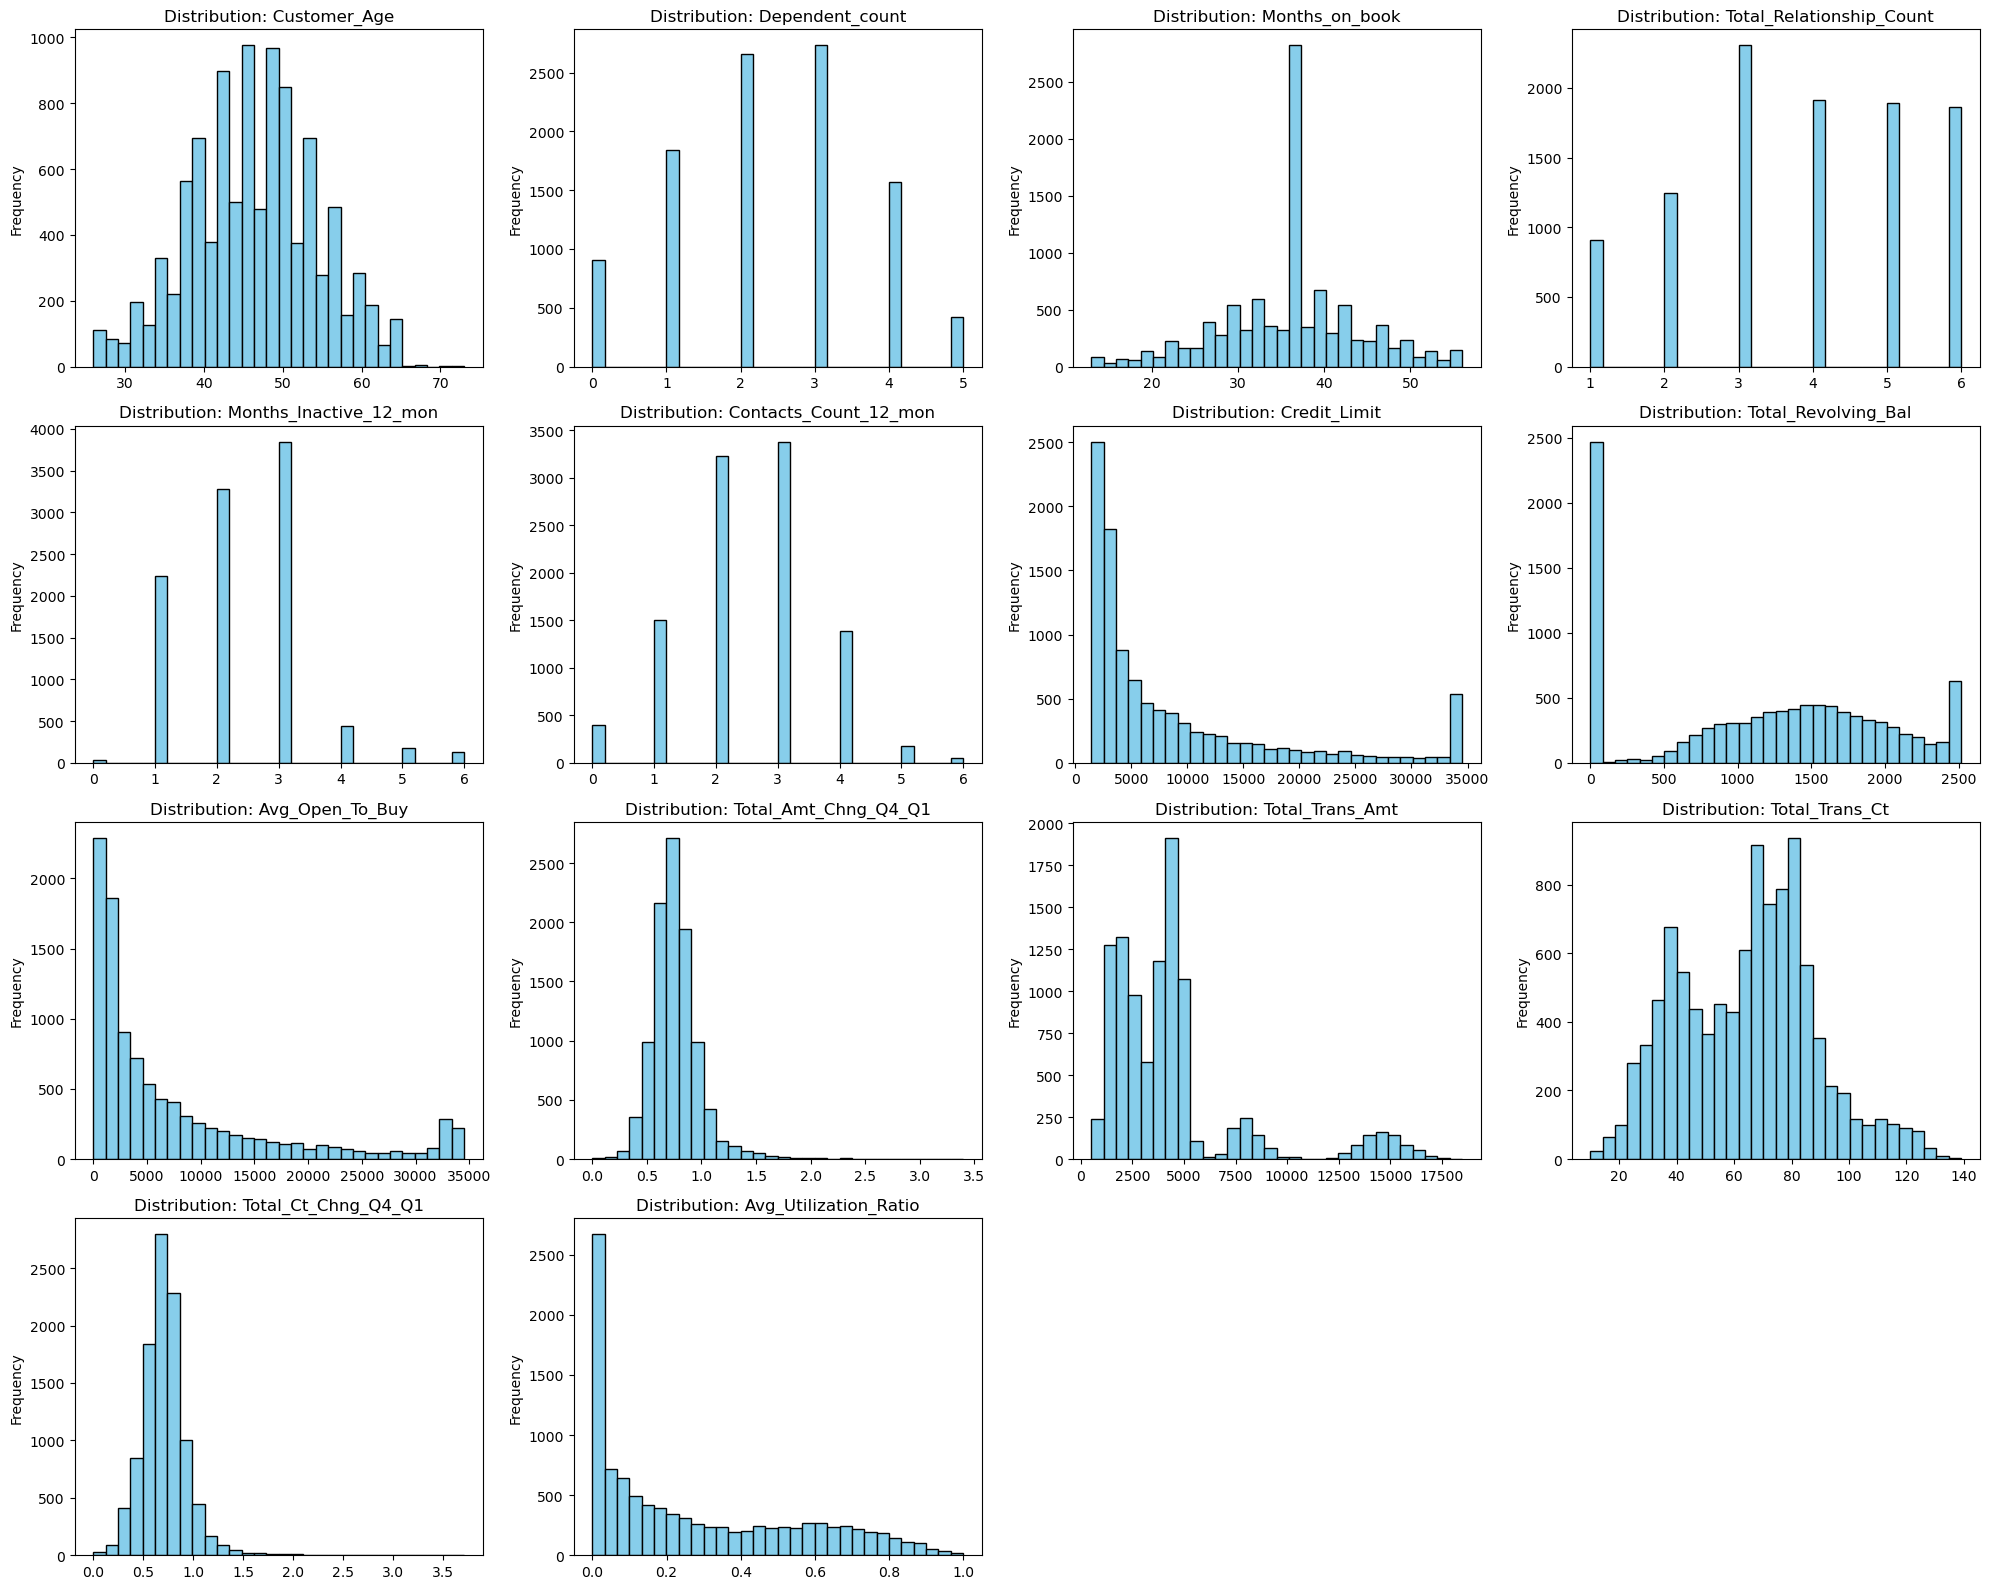

In [10]:
n_num = len(numeric_fields)
n_cols = 4  
n_rows = math.ceil(n_num / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

if n_num == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, col in zip(axes, numeric_fields):
    values = data[col]
    clean = values[~np.isnan(values)]
    ax.hist(clean, bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution: {col}')
    ax.set_ylabel('Frequency')

for i in range(n_num, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**Qua các phân bố trên, ta có thể nhận thấy một số đặc điểm:**
- Giá trị của *`Credit_Limit`* bị lệch trái, tức là lượng người dụng có hạn mức thấp tương đối cao

- Giá trị của *`Total_Revolving_Bal`* tức là tổng dư nợ trên thẻ tín dụng phân bố khá đều trừ tình huống của giá trị 0 là có tần số cao bất thường. Điều này chứng minh rằng đa số người dùng luôn duy trì lượng tổng dư nợ tín dụng là 0

- Giá trị của *`Avg_Open_To_Buy`* bị lệch trái, có nhiều người dùng có mức tín dụng còn lại trung bình khá thấp. Điều nay chứng tỏ rằng có nhiều người dùng có lượng dư nợ trung bình lớn

- Giá trị của *`Total_Trans_Amt`* bị lệch trái, điều này đồng nghĩa với việc đa số người dùng có lượng tiêu thụ trên thẻ tín dụng là tương đối trung bình thấp

- Giá trị của *`Avg_Utilization_Ratio`* là tỉ lệ sử dụng thẻ tín dụng bị lệch trái và nổi trội là tần số của giá trị 0. Điều này chứng tỏ rằng phần lớn người dùng chưa tận dụng được hết hạn mức của mình

### *Ta khảo sát thêm trong dữ liệu numeric, dữ liệu và outlier phân bổ như thế nào*

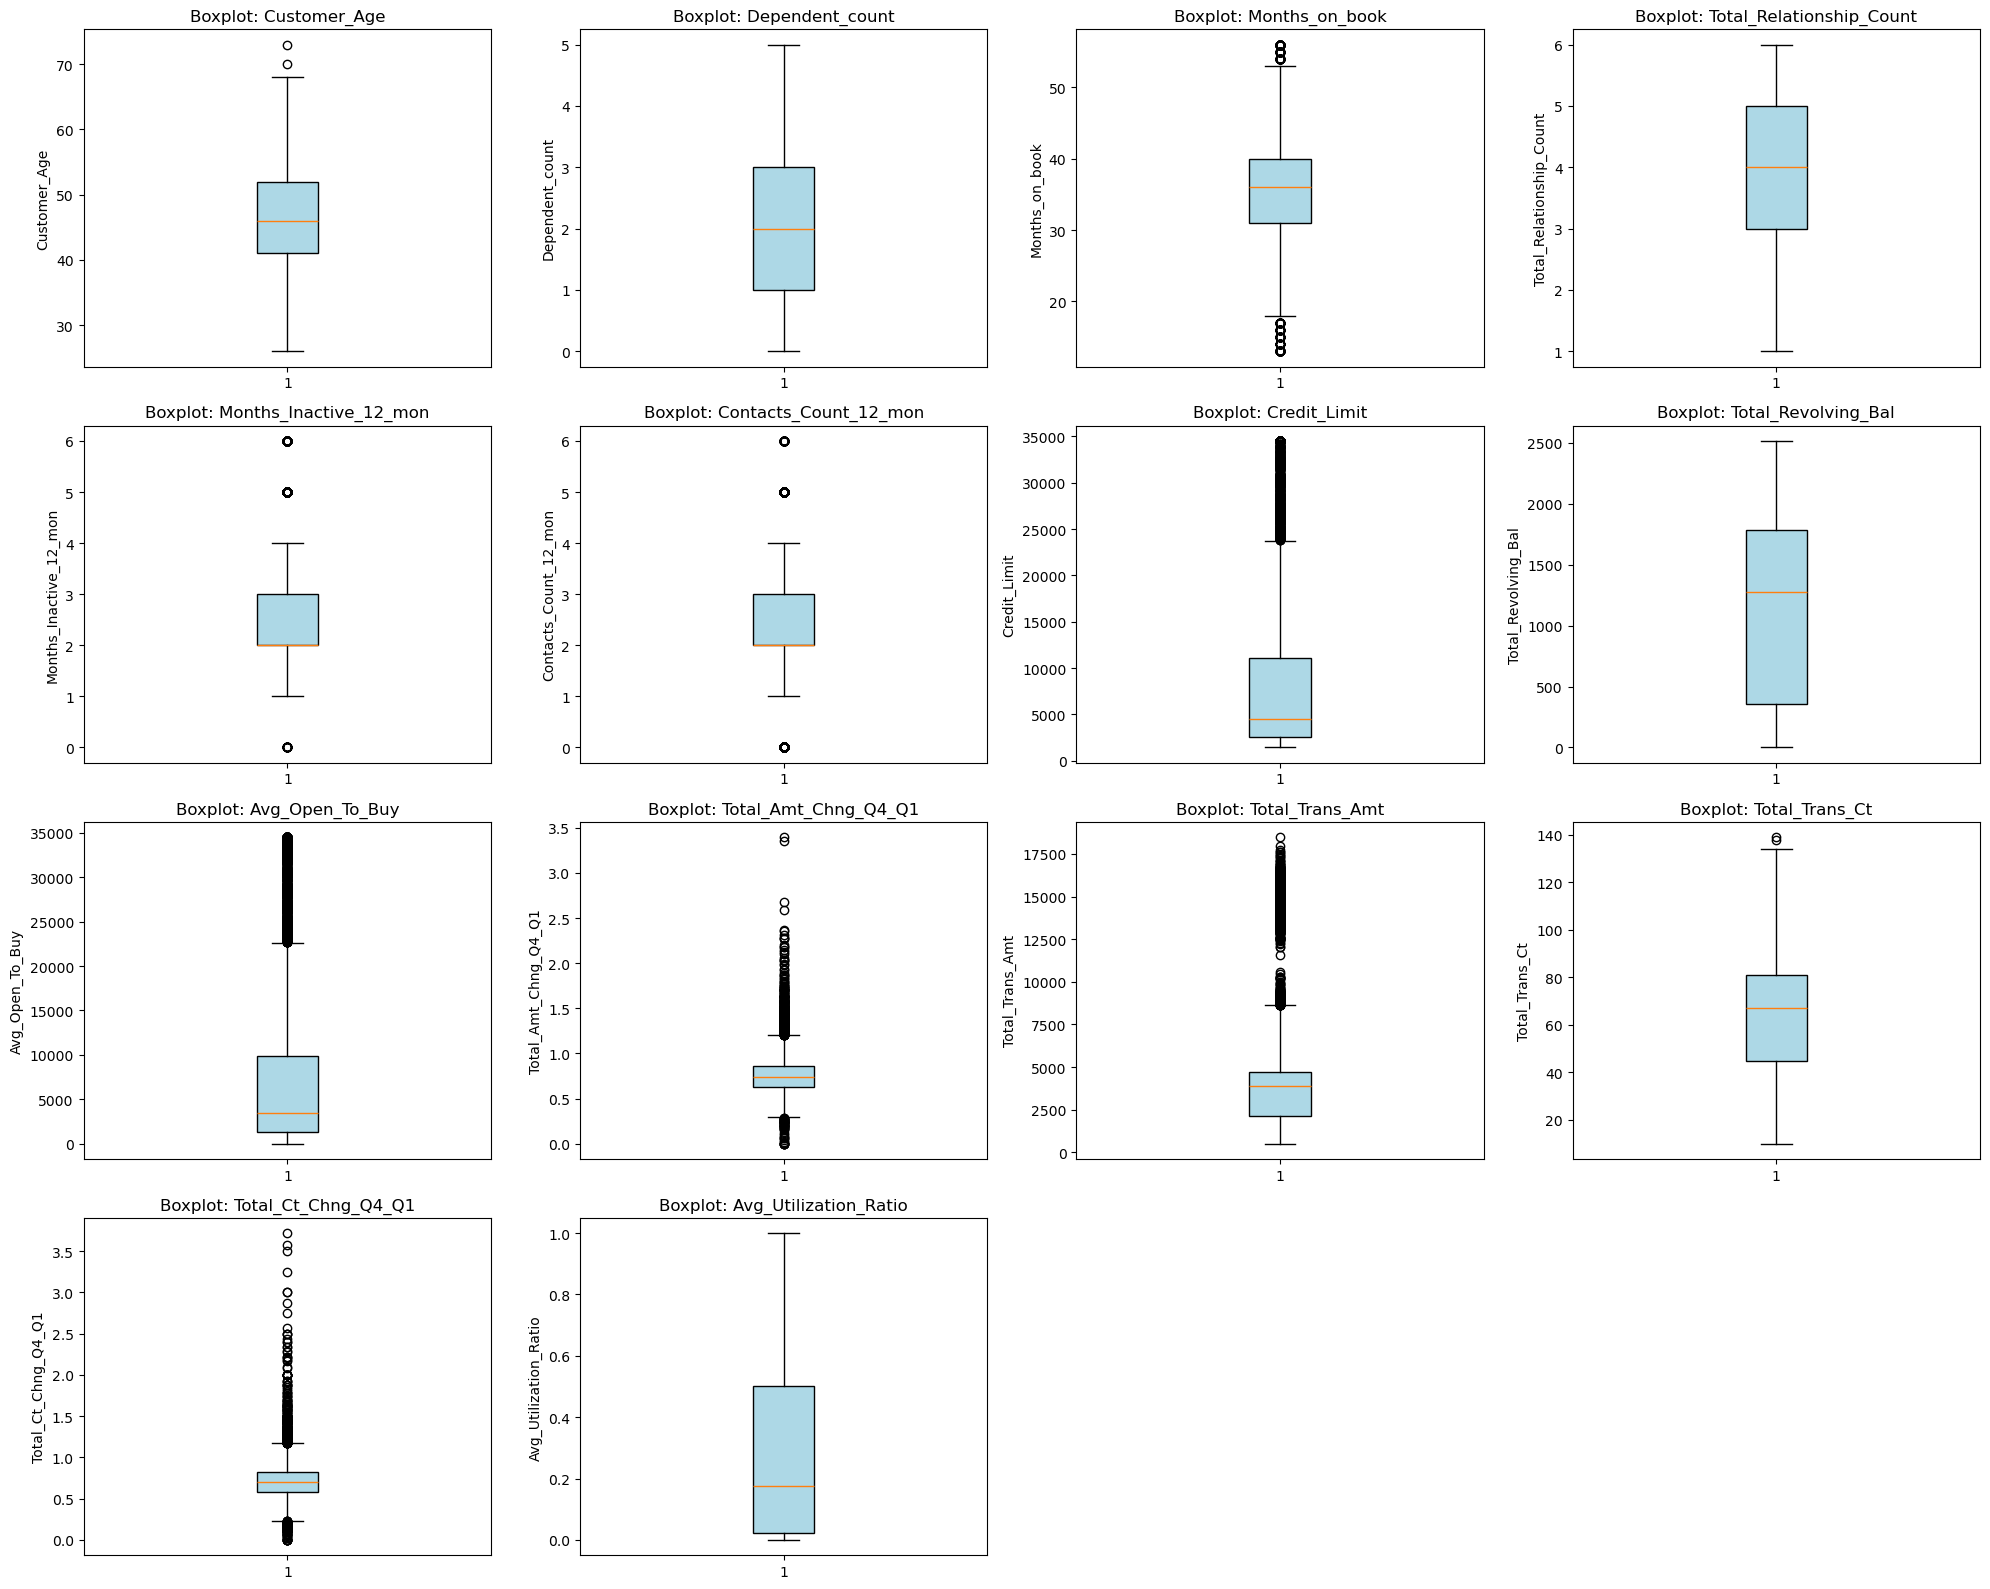

In [11]:
n_num = len(numeric_fields)
if n_num >= 1:
    n_cols = 4
    n_rows = math.ceil(n_num / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    if n_num == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, col in zip(axes, numeric_fields):
        values = data[col]
        clean = values[~np.isnan(values)]
        ax.boxplot(clean, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
        ax.set_title(f'Boxplot: {col}')
        ax.set_ylabel(col)

    for i in range(n_num, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

**Từ 14 biến số quan trọng, chia làm 4 nhóm chính:**

 *1. Nhân khẩu học & Mối quan hệ (Demographics & Relationship)*
Nhóm biến mô tả chân dung khách hàng và mức độ gắn kết với ngân hàng.

- **`Customer_Age` (Tuổi):** Phân phối chuẩn (hình chuông). Trung vị **~46 tuổi**. Tập trung chủ yếu ở nhóm trung niên (41-52 tuổi).
- **`Dependent_count` (Người phụ thuộc):** Trung vị **2 người**. Dữ liệu phân bố đều từ 0-5 người, phản ánh mô hình gia đình trọng điểm.
- **`Months_on_book` (Thâm niên):** Trung vị **36 tháng** (3 năm). Dữ liệu tập trung rất cao tại mốc này, ngoại lai xuất hiện nhiều ở cả hai đầu (khách hàng rất mới và rất cũ).
- **`Total_Relationship_Count` (Số sản phẩm):** Trung vị **4 sản phẩm**. Mức độ gắn kết cao, đa số khách hàng sử dụng từ 3-5 dịch vụ.

*2. Tín dụng & Dư nợ (Credit & Balance)*
Nhóm biến phản ánh sức khỏe tài chính và rủi ro tín dụng.

- **`Credit_Limit` (Hạn mức):** Lệch phải nặng. Trung vị thấp (~4.500), nhưng có **rất nhiều ngoại lai** giá trị cao (lên tới 35.000). Phản ánh chênh lệch lớn giữa nhóm phổ thông và nhóm VIP.
- **`Avg_Open_To_Buy` (Khả dụng):** Tương tự `Credit_Limit`. Hạn mức khả dụng còn lại của nhóm VIP rất lớn.
- **`Total_Revolving_Bal` (Dư nợ):** Trung vị **~1.300**. Phân bố trải rộng (400 - 1.800), ít ngoại lai cực đoan.
- **`Avg_Utilization_Ratio` (Tỷ lệ dùng thẻ):** Trung vị thấp (**~20%**). Phần lớn khách hàng chưa tận dụng hết hạn mức được cấp.

 *3. Hành vi Giao dịch (Transactions)*
Nhóm biến động nhất, phản ánh thói quen chi tiêu.

- **`Total_Trans_Amt` (Số tiền tiêu):** Phân hóa rõ rệt. Trung vị thấp (~4.000) nhưng có một cụm **ngoại lai lớn** tách biệt hẳn ở mức 12.500 - 17.500 (nhóm chi tiêu mạnh).
- **`Total_Trans_Ct` (Số lần tiêu):** Phân phối chuẩn hơn so với số tiền. Trung vị **~70 giao dịch/năm**.
- **`Total_Amt_Chng_Q4_Q1` & `Total_Ct_Chng_Q4_Q1` (Biến động mùa vụ):** Trung vị **< 1.0** (khoảng 0.7). Xu hướng chung là giảm hoạt động vào quý 4 so với quý 1, tuy nhiên có nhiều ngoại lai tăng trưởng đột biến.

 *4. Tương tác & Hoạt động (Interaction)*
Nhóm biến về trạng thái hoạt động của tài khoản.

- **`Months_Inactive_12_mon`:** Trung vị **2 tháng**. Khách hàng thường chỉ không hoạt động trong thời gian ngắn (2-3 tháng).
- **`Contacts_Count_12_mon`:** Trung vị **2-3 lần**. Tần suất tương tác giữa khách hàng và ngân hàng khá thấp và ổn định.

---

 **Tổng quan:**
- **Chân dung:** Khách hàng điển hình là người trung niên (46 tuổi), có gia đình, gắn bó 3 năm và dùng nhiều dịch vụ (4 sản phẩm).
- **Phân cực:** Có sự phân hóa giàu nghèo rõ rệt trong hạn mức tín dụng và số tiền chi tiêu (xuất hiện nhiều Outliers giá trị cao).
- **Cơ hội:** Tỷ lệ sử dụng thẻ còn thấp (20%), ngân hàng có dư địa để kích cầu chi tiêu mà không quá lo ngại rủi ro vượt hạn mức.

---



### *Trực quan hoá phân phối dữ liệu categorical*

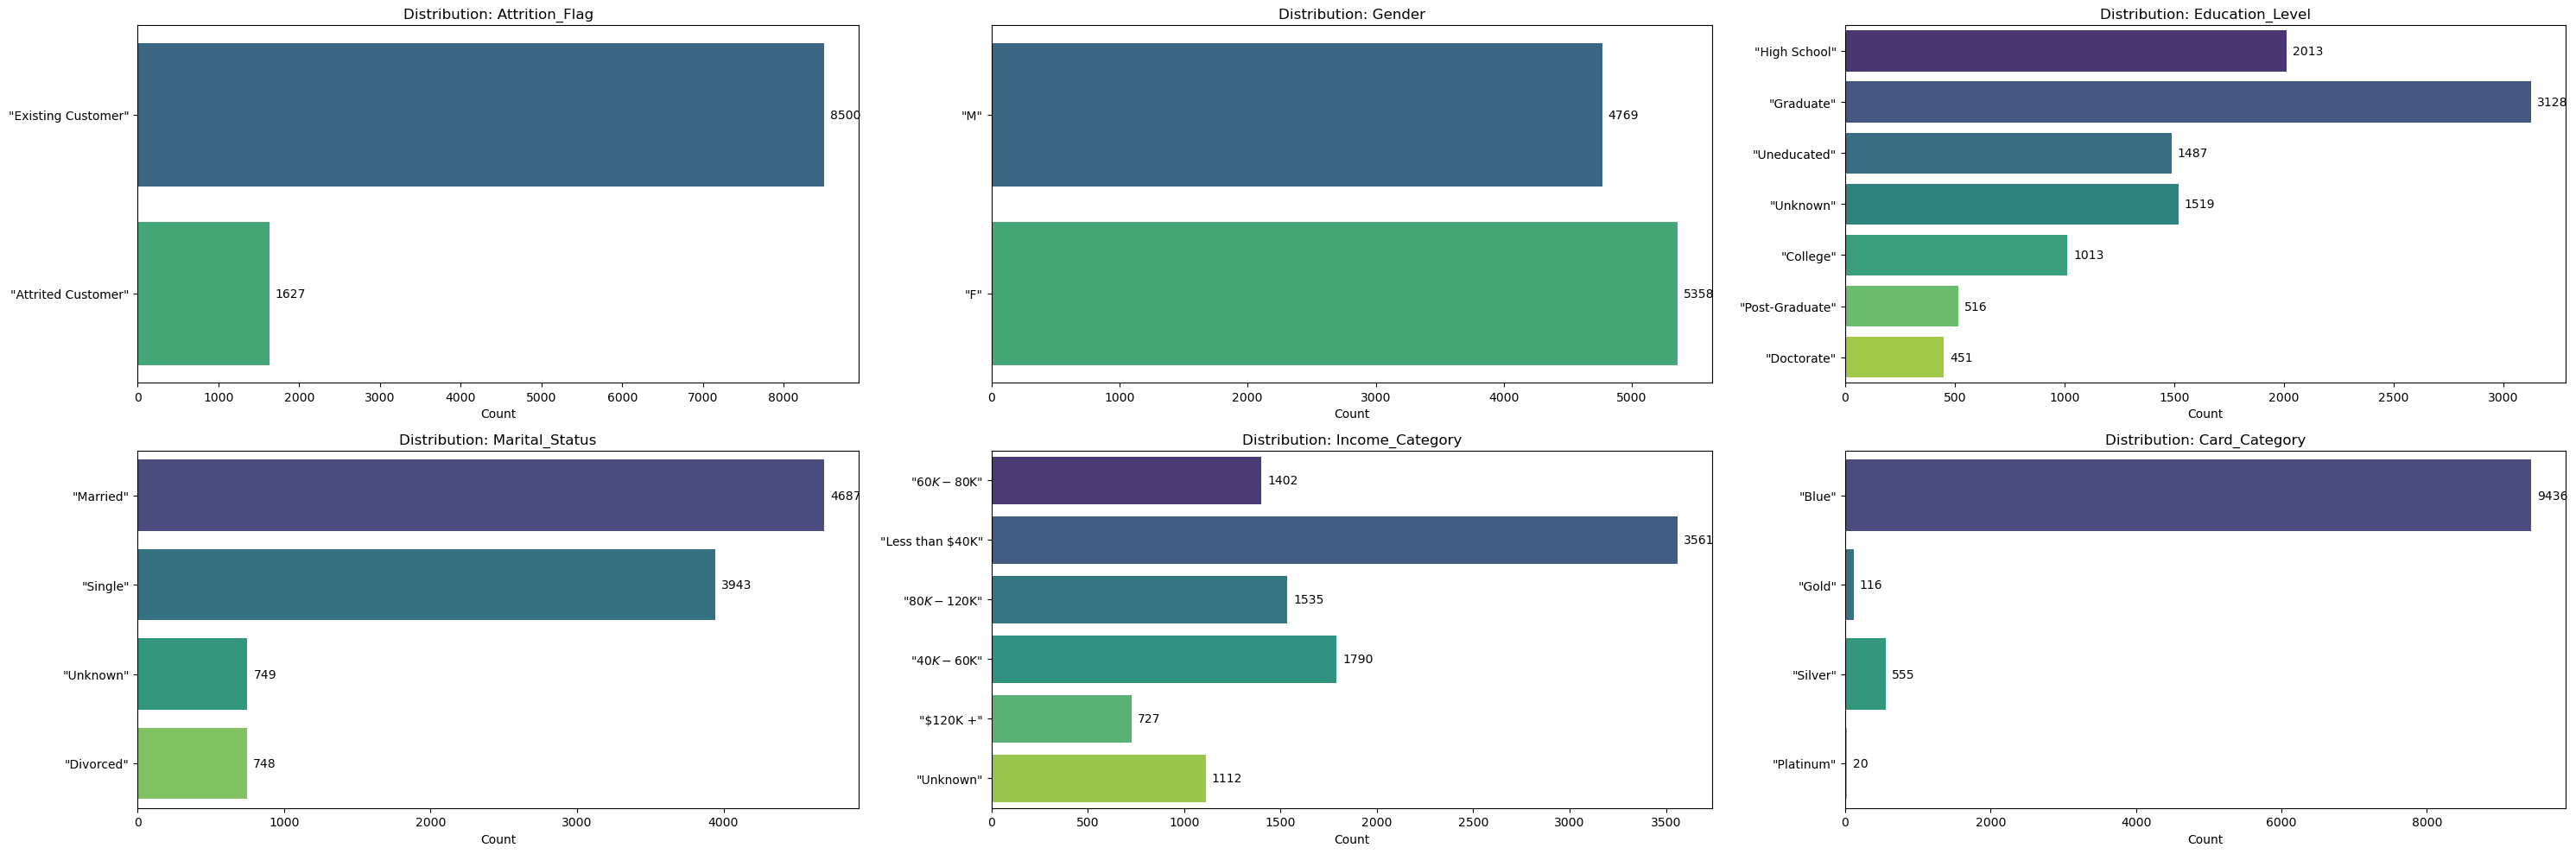

In [22]:
n_cat = len(categorical_fields)
n_cols = 3
n_rows = math.ceil(n_cat / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_fields):
    col_data = data[col]
    
    sns.countplot(y=col_data, hue=col_data, legend=False, ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_ylabel('') 
    axes[i].set_xlabel('Count')
  
    for p in axes[i].patches:
        width = p.get_width()
        
        if math.isnan(width): 
            width = 0
            
        axes[i].annotate(f'{int(width)}', 
                         (width, p.get_y() + p.get_height() / 2.), 
                         ha='left',     
                         va='center',    
                         fontsize=10,
                         xytext=(5, 0),  
                         textcoords='offset points')

for i in range(n_cat, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Từ các phân phối của các đặc trưng categorical, ta có thể nhận xét:

- Đa số người dùng đều đang sử dụng dịch vụ tín dụng của ngân hàng, chỉ có số ít là ngưng sử dụng

- Đa số người dùng dịch vụ tín dụng đều đã tốt nghiệp cử nhân và đang theo học phổ thông

- Người dùng chia thành 2 nhóm chính là nhóm đã kết hôn và nhóm còn độc thân

- Có một lượng lớn khách hợp có thu nhập hằng năm nằm ở mức thấp (dưới 40K đô)

- Đa số người dùng dịch vụ tín dụng thì có loại thẻ là thẻ xanh (thấp nhất)

### *Ngoài ra, ta sẽ thống kê xem các giá trị duy nhất trong từng đặc trưng categorical có bao nhiêu phần trăm nằm trong nhóm người dùng rời đi khỏi dịch vụ tín dụng*

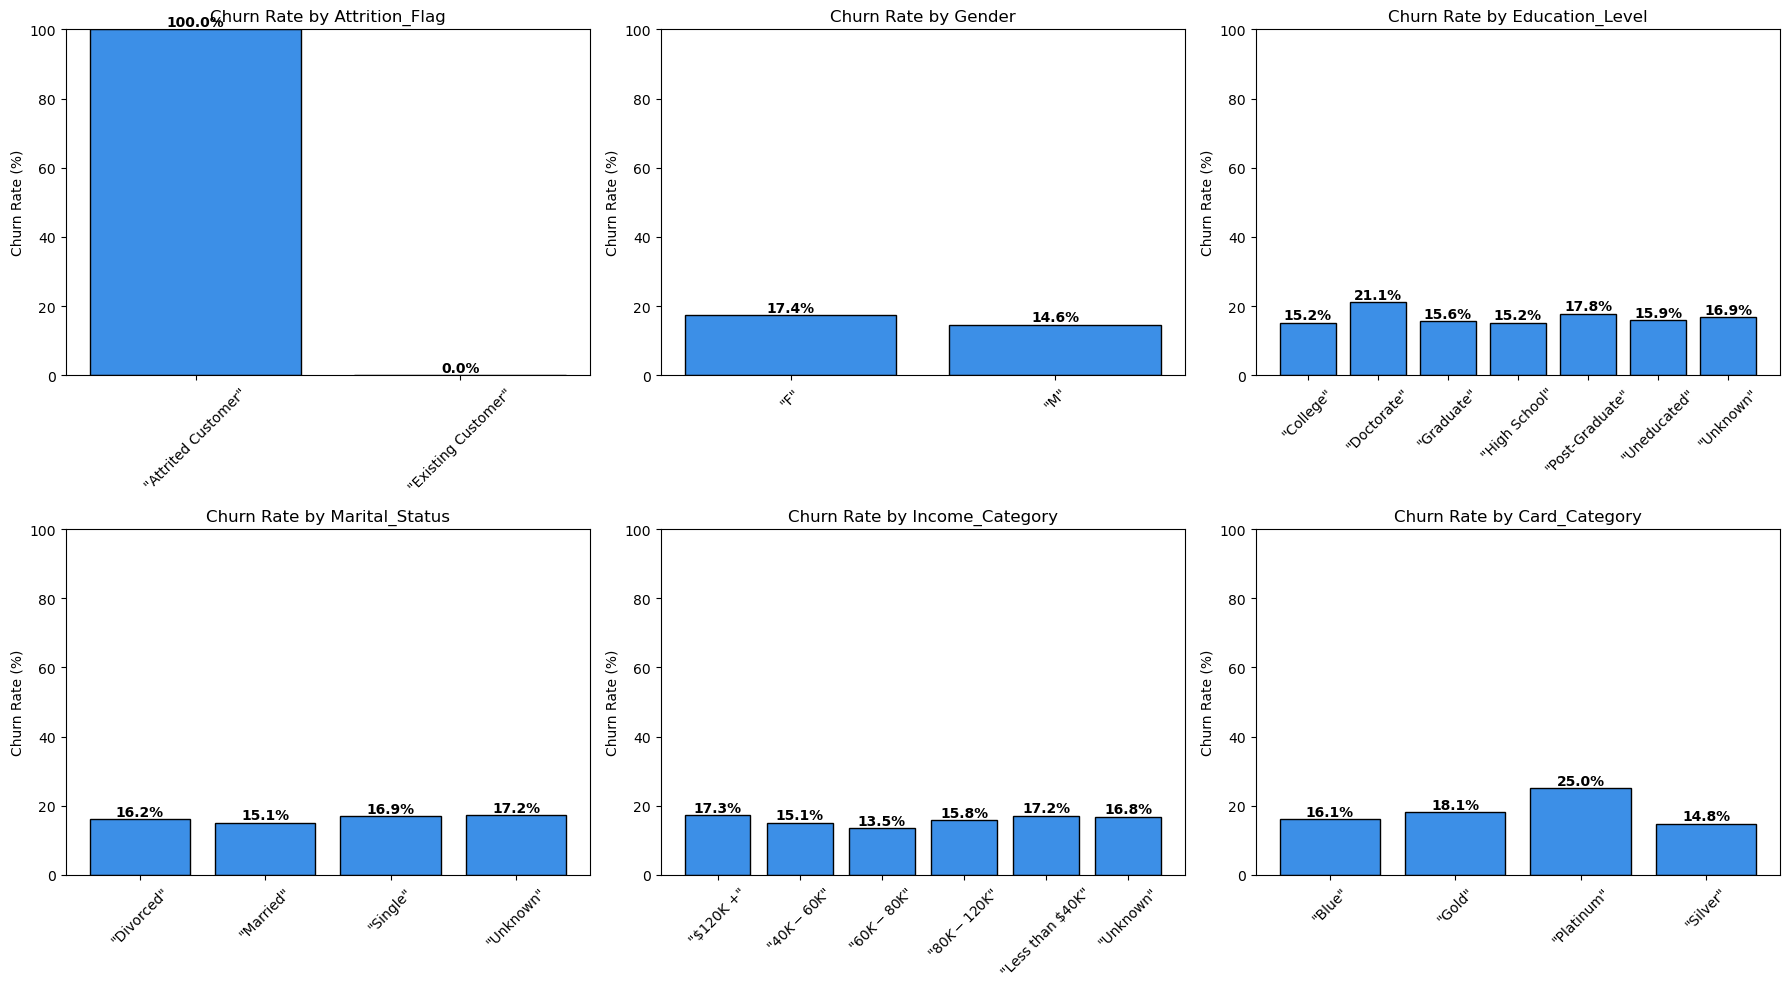

In [14]:
target_col = 'Attrition_Flag'
churn_label = '"Attrited Customer"'
def calculate_churn_rate(data, feature_col, target_col, churn_label):
    feature_data = data[feature_col]
    target_data = data[target_col]
    
    unique_vals = np.unique(feature_data)
    churn_rates = []
    
    for val in unique_vals:
        group_mask = (feature_data == val)
        
        total_in_group = np.sum(group_mask)
        
        churn_mask = group_mask & (target_data == churn_label)
        churn_count = np.sum(churn_mask)
        
        rate = (churn_count / total_in_group) * 100
        churn_rates.append(rate)
        
    return unique_vals, churn_rates

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_fields):
    categories, rates = calculate_churn_rate(data, col, target_col , churn_label)
    
    axes[i].bar(categories, rates, color="#3c8fe7", edgecolor='black')
    
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 100) 
    axes[i].tick_params(axis='x', rotation=45)
    
    for j, rate in enumerate(rates):
        axes[i].text(j, rate + 1, f'{rate:.1f}%', ha='center', fontweight='bold')

# Xóa axes thừa
for i in range(n_cat, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Nhóm người dùng rời đi phân bố khá đồng đều vào các giá trị của từng đặc trưng categorical

## **Kiểm tra sự tương quan của dữ liệu:**

### *Khảo sát Pearson heatmap của dữ liệu numeric*

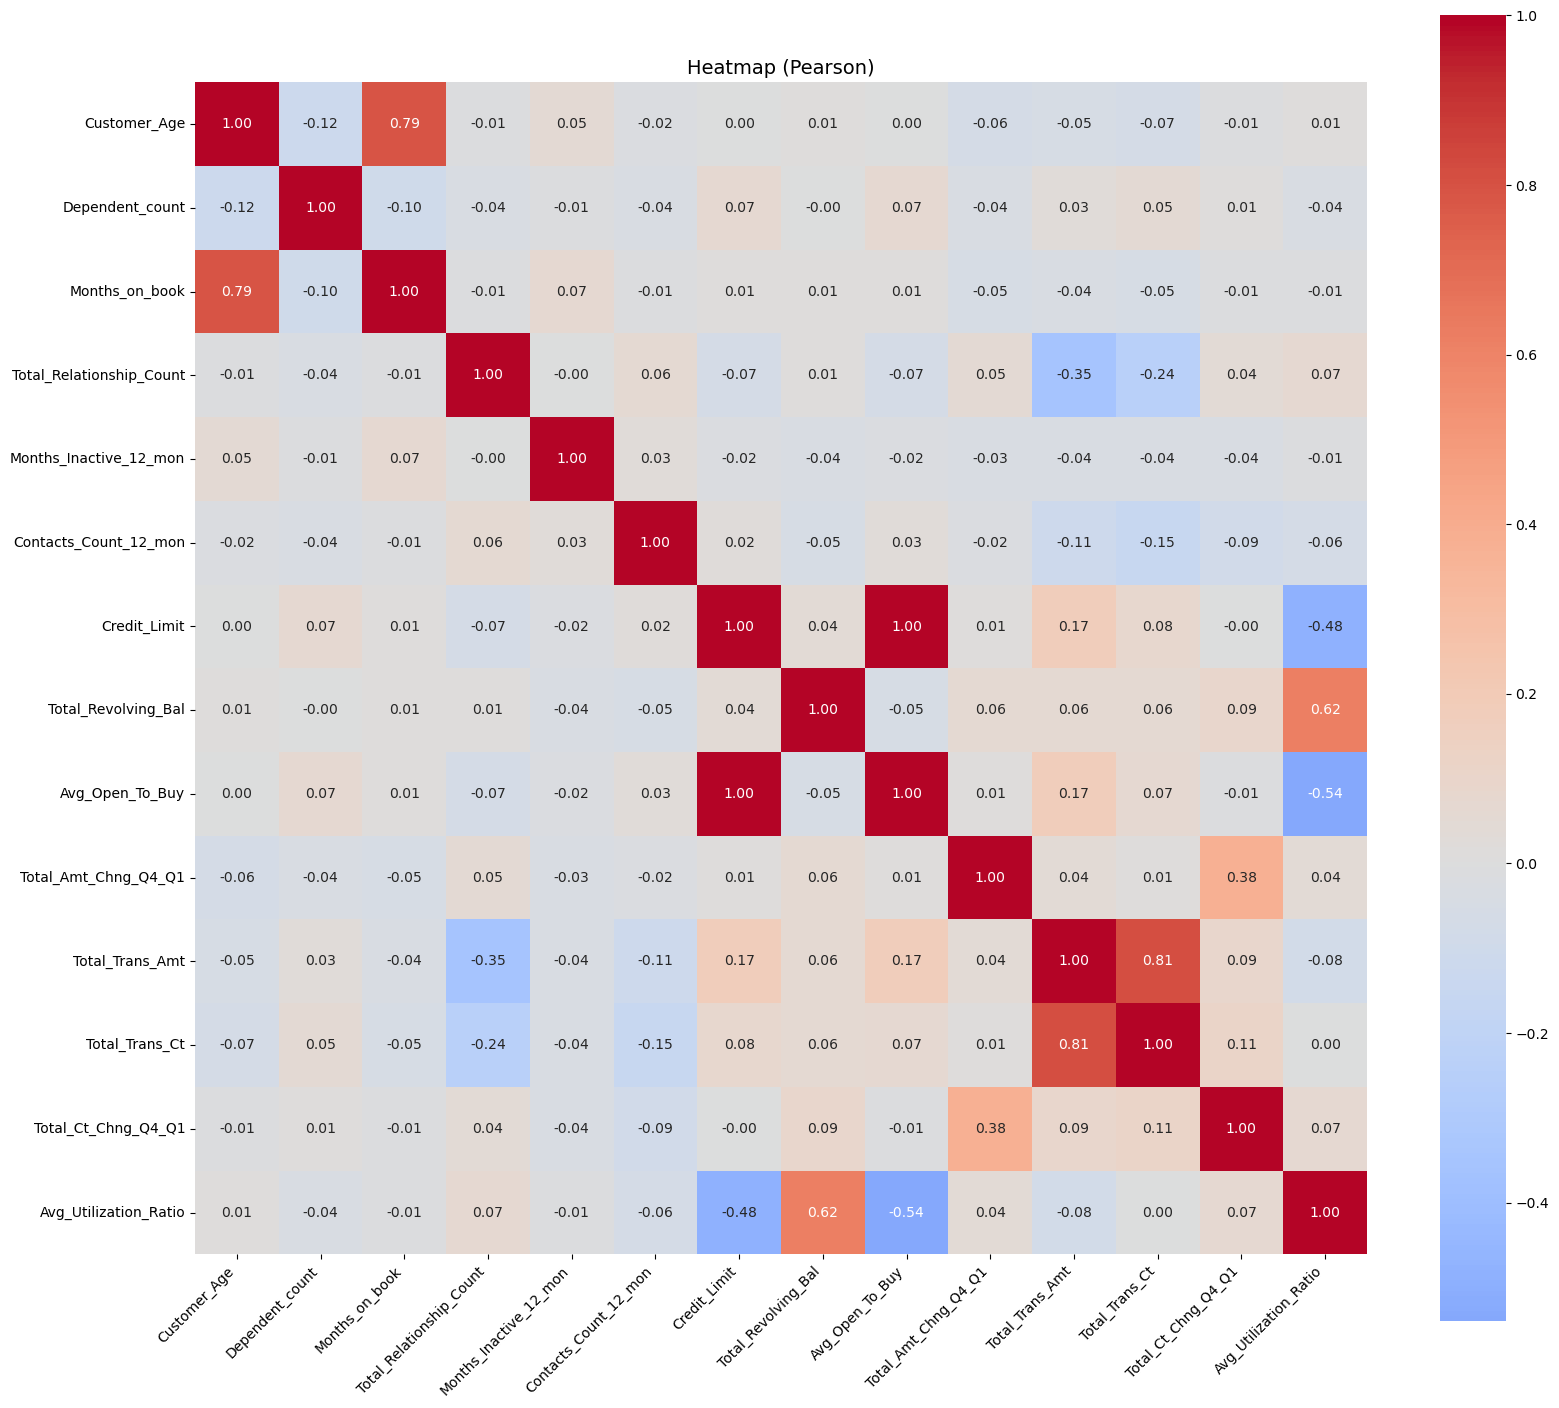

In [15]:
if len(numeric_fields) > 1:
    # Ghép cột số thành mảng 2D
    numeric_matrix = np.column_stack([data[col] for col in numeric_fields])
    
    # Tính correlation 
    corr = np.corrcoef(numeric_matrix, rowvar=False)
    corr_rounded = np.round(corr, 2)
    
    n = len(numeric_fields)
    figsize = max(6, n * 1.2)  
    
    plt.figure(figsize=(figsize, figsize))
    
    sns.heatmap(
        corr_rounded,
        xticklabels=numeric_fields,
        yticklabels=numeric_fields,
        annot=True,
        fmt=".2f",             # Hiển thị 2 chữ số thập phân
        cmap='coolwarm',
        center=0,
        square=True,           # Ô vuông cho dễ nhìn
        cbar_kws={"shrink": 0.8}
    )
    
    plt.title('Heatmap (Pearson)', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

**Từ ma trận tương quan Pearson trên, ta có các nhận xét về mối quan hệ của các đặc trung:**
- Tuổi của người dùng **`Customer_Age`** có độ tương quan tương đối cao với thời gian gắn bó với dịch vụ của ngân hàng **`Months_on_Book`**

- Tổng lượng tiêu thụ của người dùng **`Total_Trans_Amt`** có độ tương đồng cao với số lần giao dịch **`Total_Trans_Ct`** --> số lần tiêu thụ nhiều dẫn đến lượng tiêu thụ tăng

- Tổng dư nợ của người dùng **`Total_Revolving_Bal`** có độ tương đồng trung bình khá với trung bình tỉ lệ sử dụng hạn mức tín dụng **`Avg_Utilization_Ratio`** (tỉ lệ nợ trên hạn mức)

- Hạn mức tín dụng của người dùng **`Credit_Limit`** có độ tương đồng hoàn toàn với trung bình hạn mức còn lại trong 12 tháng của người dùng **`Avg_Open_To_Buy`**, điều này đồng nghĩa với việc nếu một người dùng có hạn mức cao thì họ luôn có trung bình hạn mức còn lại sau nợ của mình gần như là bằng với hạn mức hiện tại của họ, hay nói cách khác họ có tổng dư nợ trung bình là 0 --> Người dùng có hạn mức cao thường luôn trả nợ tín dụng đúng kỳ hạn để không bị phạt

### *Kiểm định Chi-square (Chi bình phương) trên dữ liệu categorical*
Ta phát biểu giả thiết:

$H_0:$ 2 đặc trưng là độc lập

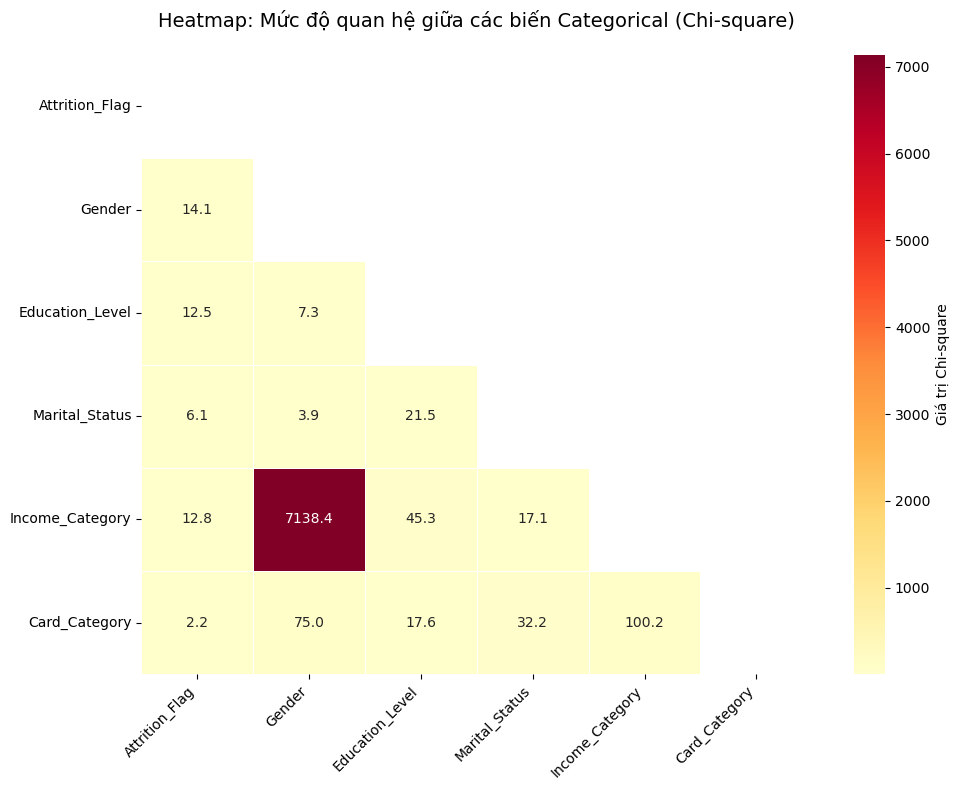

Cặp đặc trưng (Feature Pair),Chi-square (χ²),Degrees of Freedom (df),Critical Value,Kết luận
Attrition_Flag ↔ Gender,14.07,1,3.841,PHỤ THUỘC
Attrition_Flag ↔ Education_Level,12.51,6,12.592,ĐỘC LẬP
Attrition_Flag ↔ Marital_Status,6.06,3,7.815,ĐỘC LẬP
Attrition_Flag ↔ Income_Category,12.83,5,11.07,PHỤ THUỘC
Attrition_Flag ↔ Card_Category,2.23,3,7.815,ĐỘC LẬP
Gender ↔ Education_Level,7.29,6,12.592,ĐỘC LẬP
Gender ↔ Marital_Status,3.88,3,7.815,ĐỘC LẬP
Gender ↔ Income_Category,7138.45,5,11.07,PHỤ THUỘC
Gender ↔ Card_Category,75.01,3,7.815,PHỤ THUỘC
Education_Level ↔ Marital_Status,21.51,18,28.869,ĐỘC LẬP


In [17]:
# Bảng giá trị tới hạn Chi-square (User provided)
chi2_critical = {1: 3.841, 2: 5.991, 3: 7.815, 4: 9.488, 5: 11.070, 6: 12.592, 7: 14.067, 8: 15.507, 9: 16.919, 10: 18.307, 11: 19.675, 12: 21.026, 13: 22.362, 14: 23.685, 15: 24.996, 16: 26.296, 17: 27.587, 18: 28.869, 19: 30.144, 20: 31.410}

n_cat = len(categorical_fields)
chi2_matrix = np.zeros((n_cat, n_cat))
independence_matrix = np.full((n_cat, n_cat), True)
results_list = [] 

for i in range(n_cat):
    for j in range(n_cat):
        if i == j: continue

        col1 = data[categorical_fields[i]]
        col2 = data[categorical_fields[j]]

        # Tạo contingency table
        unique1, inv1 = np.unique(col1, return_inverse=True)
        unique2, inv2 = np.unique(col2, return_inverse=True)
        contingency = np.zeros((len(unique1), len(unique2)), dtype=int)
        for idx in range(len(inv1)):
            contingency[inv1[idx], inv2[idx]] += 1

        # Tính Expected & Chi2
        row_sums = contingency.sum(axis=1, keepdims=True)
        col_sums = contingency.sum(axis=0, keepdims=True)
        total = contingency.sum()
        expected = (row_sums @ col_sums) / total
        
        mask = expected > 0
        chi2 = np.sum(((contingency - expected)**2 / expected)[mask])
        chi2_matrix[i, j] = chi2

        # Kiểm định
        df = (contingency.shape[0] - 1) * (contingency.shape[1] - 1)
        critical_val = chi2_critical.get(df, np.inf)
        is_independent = chi2 <= critical_val
        independence_matrix[i, j] = is_independent

        # Chỉ lưu kết quả 1 lần cho mỗi cặp (khi j > i) để hiển thị bảng
        if j > i:
            results_list.append({
                'pair': f"<b>{categorical_fields[i]}</b> <br>↔ {categorical_fields[j]}",
                'chi2': chi2,
                'df': df,
                'critical': critical_val,
                'status': "ĐỘC LẬP" if is_independent else "PHỤ THUỘC"
            })


# Vẽ Heatmap
plt.figure(figsize=(10, 8))
mask_tri = np.triu(np.ones_like(chi2_matrix, dtype=bool)) # Che nửa trên
sns.heatmap(
    chi2_matrix,
    mask=mask_tri,
    xticklabels=categorical_fields,
    yticklabels=categorical_fields,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Giá trị Chi-square'}
)
plt.title("Heatmap: Mức độ quan hệ giữa các biến Categorical (Chi-square)", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

html_table = """
<h3 style="color: #2c3e50; margin-top: 30px;"> KẾT QUẢ KIỂM ĐỊNH ĐỘC LẬP (α = 0.05)</h3>
<table style="width: 100%; border-collapse: collapse; font-family: sans-serif; box-shadow: 0 0 20px rgba(0,0,0,0.1);">
    <thead style="background-color: #34495e; color: white;">
        <tr>
            <th style="padding: 12px; text-align: left;">Cặp đặc trưng (Feature Pair)</th>
            <th style="padding: 12px; text-align: right;">Chi-square (χ²)</th>
            <th style="padding: 12px; text-align: center;">Degrees of Freedom (df)</th>
            <th style="padding: 12px; text-align: center;">Critical Value</th>
            <th style="padding: 12px; text-align: center;">Kết luận</th>
        </tr>
    </thead>
    <tbody>
"""

for item in results_list:
    # Logic màu sắc cho Badge
    if item['status'] == "PHỤ THUỘC":
        badge_style = "background-color: #e74c3c; color: white; padding: 5px 10px; border-radius: 15px; font-weight: bold; font-size: 0.9em;"
        row_style = "background-color: #fff5f5; border-bottom: 1px solid #eee;"
    else:
        badge_style = "background-color: #95a5a6; color: white; padding: 5px 10px; border-radius: 15px; font-weight: bold; font-size: 0.9em;"
        row_style = "border-bottom: 1px solid #eee;"

    html_table += f"""
        <tr style="{row_style}">
            <td style="padding: 10px;">{item['pair']}</td>
            <td style="padding: 10px; text-align: right; font-family: monospace; font-size: 1.1em;">{item['chi2']:.2f}</td>
            <td style="padding: 10px; text-align: center;">{item['df']}</td>
            <td style="padding: 10px; text-align: center; color: #7f8c8d;">{item['critical']}</td>
            <td style="padding: 10px; text-align: center;"><span style="{badge_style}">{item['status']}</span></td>
        </tr>
    """

html_table += "</tbody></table>"
display(HTML(html_table))

## **Mục tiêu phân tích**
Trong phần phân tích dữ liệu này, chúng ta sẽ trả lời các câu hỏi cốt lõi sau để tìm hiểu nguyên nhân khách hàng rời bỏ dịch vụ tín dụng:

1. Tình trạng hiện tại: Tỷ lệ khách hàng rời bỏ là bao nhiêu?

2. Yếu tố nhân khẩu học: Độ tuổi, giới tính hay trình độ học vấn có ảnh hưởng đến quyết định rời bỏ không?

3. Hành vi tài chính: Có sự khác biệt nào về hạn mức tín dụng và tổng dư nợ giữa hai nhóm khách hàng?

4. Hành vi giao dịch: Tần suất và số tiền giao dịch có phải là dấu hiệu cảnh báo sớm về việc một người dùng rời đi hay không?

### *Câu hỏi số 1: Tỷ lệ khách hàng rời bỏ là bao nhiêu*


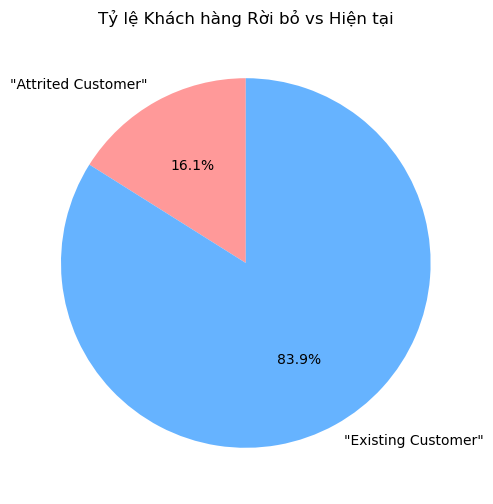

In [13]:
# Tính toán tỷ lệ
target_counts = np.unique(data['Attrition_Flag'], return_counts=True)
labels = target_counts[0]
counts = target_counts[1]

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Tỷ lệ Khách hàng Rời bỏ vs Hiện tại')
plt.show()

**Nhận xét:** Tỷ lệ khách hàng rời bỏ là 16.1%. Tập dữ liệu trên mất cân bằng về nhóm người dùng hiện tại

### *Câu hỏi số 2: Độ tuổi, giới tính hay trình độ học vấn có ảnh hưởng đến quyết định rời bỏ không?*


#### Về sự ảnh hưởng của độ tuổi

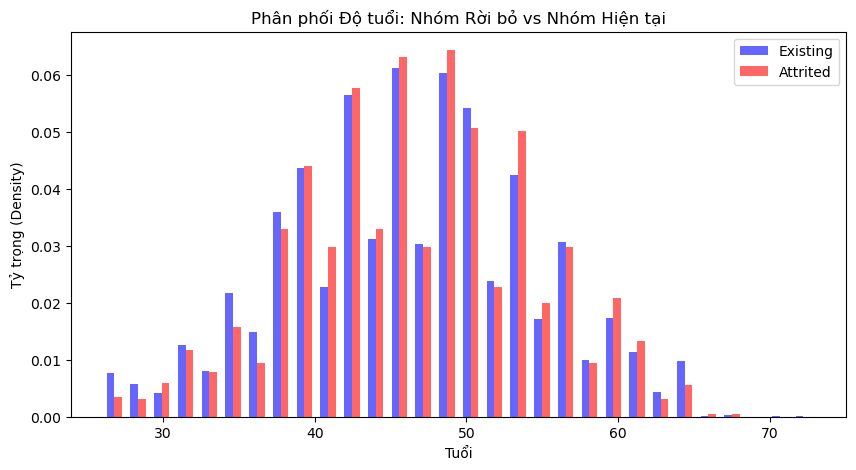

In [14]:
attrited_mask = data['Attrition_Flag'] == '"Attrited Customer"'
existing_mask = data['Attrition_Flag'] == '"Existing Customer"'

age_attrited = data['Customer_Age'][attrited_mask]
age_existing = data['Customer_Age'][existing_mask]

# Vẽ Histogram cạnh nhau
plt.figure(figsize=(10, 5))
plt.hist([age_existing, age_attrited], 
         bins=30, 
         label=['Existing', 'Attrited'], 
         color=['blue', 'red'], 
         density=True,      
         alpha=0.6,
         rwidth=0.65)         

plt.title('Phân phối Độ tuổi: Nhóm Rời bỏ vs Nhóm Hiện tại')
plt.xlabel('Tuổi')
plt.ylabel('Tỷ trọng (Density)')
plt.legend()
plt.show()

**Nhận xét từ biểu đồ phân phối độ tuổi:**

1. Phân phối tương đồng: Biểu đồ cho thấy cấu trúc độ tuổi của nhóm khách hàng rời bỏ (màu đỏ) và nhóm hiện tại (màu xanh) có hình dáng rất giống nhau (dạng phân phối chuẩn).

2. Tập trung ở trung niên: Cả hai nhóm đều tập trung chủ yếu ở độ tuổi 40-50.

*Kết luận:* Không có sự khác biệt rõ rệt về hành vi rời bỏ giữa các nhóm tuổi khác nhau. Điều này gợi ý rằng Độ tuổi `Customer_Age` không phải là đặc trưng quan trọng để phân biệt khách hàng rời bỏ. Chúng ta cần tìm kiếm nguyên nhân ở các biến số khác (như hành vi giao dịch hoặc tài chính).

#### Về ảnh hưởng của giới tính và trình độ học vấn

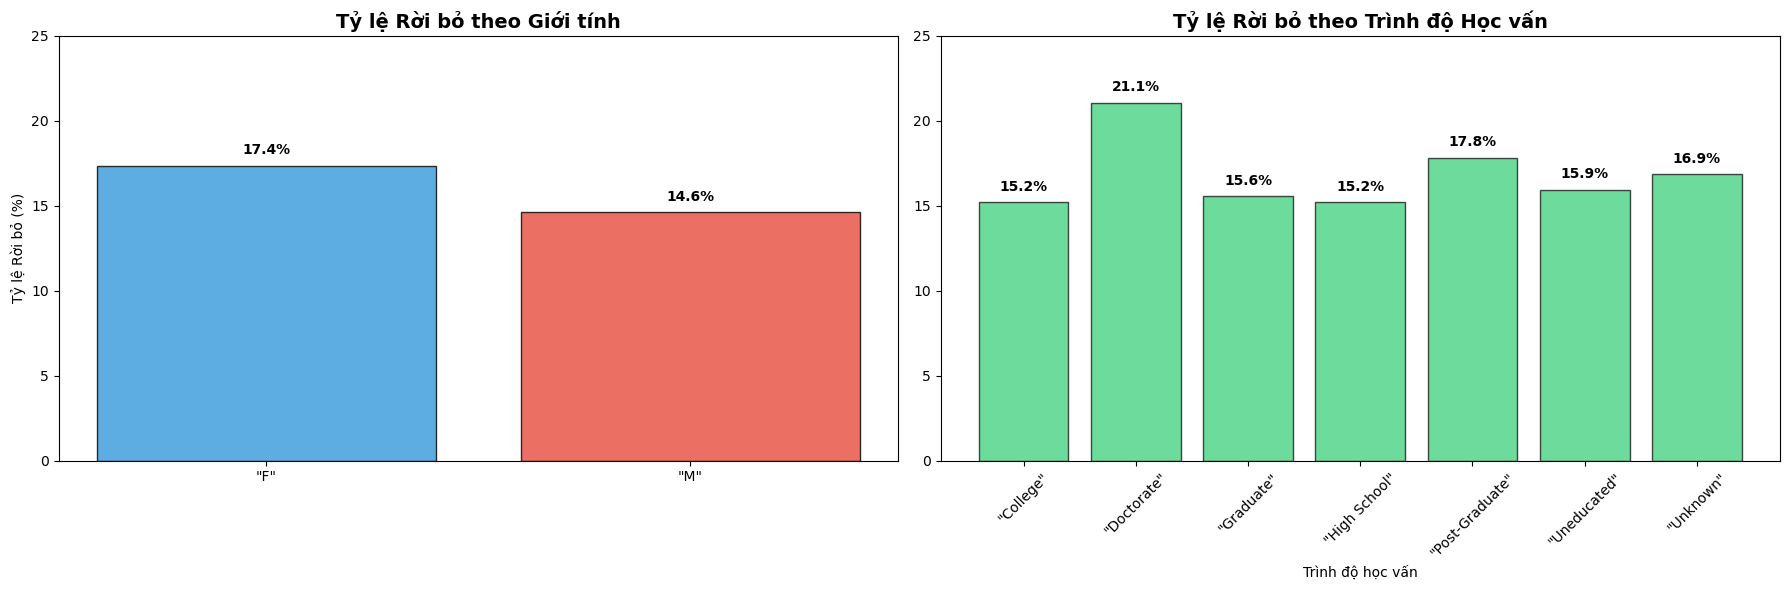

In [15]:
def calculate_churn_rate_by_category(data, feature_col):
    categories = np.unique(data[feature_col])
    rates = []
    
    for cat in categories:
        total_in_group = np.sum(data[feature_col] == cat)
        
        # Số khách hàng rời bỏ trong nhóm này
        churn_in_group = np.sum((data[feature_col] == cat) & (data['Attrition_Flag'] == '"Attrited Customer"'))
        
        # Tính tỷ lệ %
        if total_in_group > 0:
            rate = (churn_in_group / total_in_group) * 100
        else:
            rate = 0
        rates.append(rate)
        
    return categories, rates

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) 

# --- Biểu đồ 1: Ảnh hưởng của Giới tính ---
gender_cats, gender_rates = calculate_churn_rate_by_category(data, 'Gender')
bars1 = axes[0].bar(gender_cats, gender_rates, color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')

axes[0].set_title('Tỷ lệ Rời bỏ theo Giới tính', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Rời bỏ (%)')
axes[0].set_ylim(0, 25) 

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    

edu_cats, edu_rates = calculate_churn_rate_by_category(data, 'Education_Level')
bars2 = axes[1].bar(edu_cats, edu_rates, color='#2ecc71', alpha=0.7, edgecolor='black')

axes[1].set_title('Tỷ lệ Rời bỏ theo Trình độ Học vấn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Trình độ học vấn')
axes[1].set_ylim(0, 25)
axes[1].tick_params(axis='x', rotation=45) # Xoay nhãn trục x để không bị chồng chéo

# Thêm số liệu lên cột
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Phân tích Tỷ lệ Rời bỏ theo Nhân khẩu học:**

1. Giới tính: Quan sát thấy nữ giới có xu hướng rời bỏ dịch vụ cao hơn nam giới (17.4% so với 14.6%). Tuy nhiên, sự chênh lệch này không quá lớn để khẳng định giới tính là nguyên nhân duy nhất.

2. Trình độ học vấn: Có một sự phân hóa thú vị. Nhóm khách hàng có trình độ học vấn cao nhất (Doctorate) lại chính là nhóm có tỷ lệ rời bỏ cao nhất (21.1%), cao hơn hẳn mức trung bình của toàn bộ tập dữ liệu. Ngược lại, nhóm tốt nghiệp Đại học (College) và Trung học (High School) có mức độ trung thành cao hơn (tỷ lệ rời bỏ chỉ khoảng 15.2%).

Giả thuyết: Có thể nhóm khách hàng có học vị cao (Tiến sĩ, Sau đại học) có thu nhập tốt hơn và tiếp cận được nhiều ưu đãi từ các ngân hàng đối thủ, dẫn đến mức độ trung thành thấp hơn nếu dịch vụ không đáp ứng kỳ vọng.

### *Câu hỏi số 3: Có sự khác biệt nào về hạn mức tín dụng và tổng dư nợ giữa hai nhóm khách hàng?*

#### Hạn mức tín dụng `Credit_Limit`

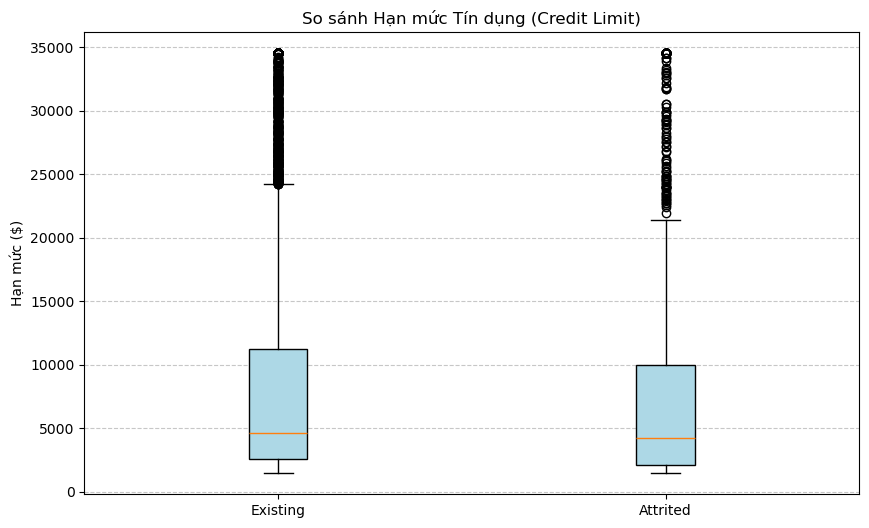

Trung bình hạn mức - Existing: 8726.88
Trung bình hạn mức - Attrited: 8136.04


In [16]:
credit_limit_attrited = data['Credit_Limit'][attrited_mask]
credit_limit_existing = data['Credit_Limit'][existing_mask]

# Vẽ Boxplot so sánh
plt.figure(figsize=(10, 6))
plt.boxplot([credit_limit_existing, credit_limit_attrited], 
            labels=['Existing', 'Attrited'], 
            patch_artist=True,  # Tô màu cho hộp
            boxprops=dict(facecolor='lightblue')) # Màu hộp
plt.title('So sánh Hạn mức Tín dụng (Credit Limit)')
plt.ylabel('Hạn mức ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# In ra số liệu thống kê để dẫn chứng cụ thể
print(f"Trung bình hạn mức - Existing: {np.mean(credit_limit_existing):.2f}")
print(f"Trung bình hạn mức - Attrited: {np.mean(credit_limit_attrited):.2f}")

**Phân tích tỉ lệ rời bỏ theo hạn mức tín dụng:**
1. Hai nhóm có trung vị và trung bình hạn mức tương đồng nhau
2. Cả hai nhóm đều có các outlier ở hạn mức rất cao, điều này đồng nghĩa với việc cả hai nhóm đều có khách hàng VIP

**Kết luận:** Hạn mức tín dụng dường như không phải là yếu tố phân biệt rõ rệt giữa người đi và người ở.

#### Tổng dư nợ `Total_Revolving_Bal`

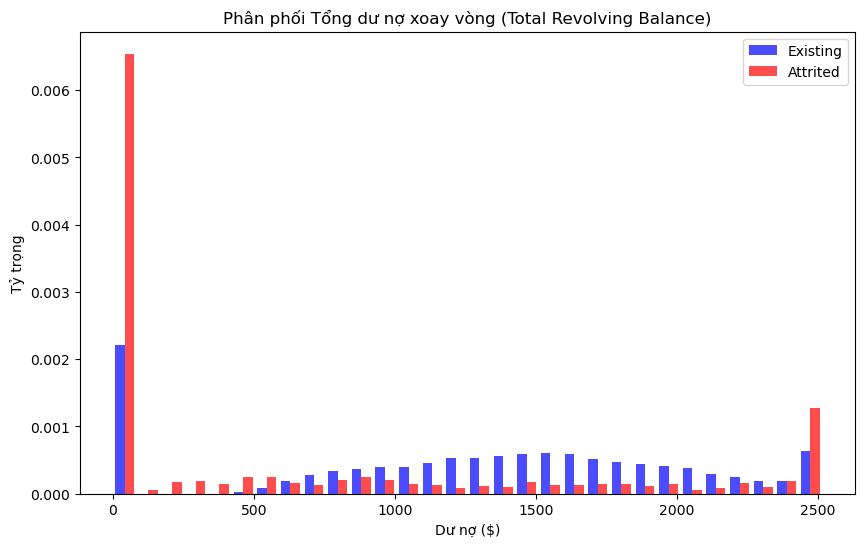

In [17]:
# Lấy dữ liệu
bal_attrited = data['Total_Revolving_Bal'][attrited_mask]
bal_existing = data['Total_Revolving_Bal'][existing_mask]

# Vẽ Histogram
plt.figure(figsize=(10, 6))
plt.hist([bal_existing, bal_attrited], 
         bins=30, 
         label=['Existing', 'Attrited'], 
         color=['blue', 'red'], 
         density=True, 
         alpha=0.7,
         rwidth=0.8)

plt.title('Phân phối Tổng dư nợ xoay vòng (Total Revolving Balance)')
plt.xlabel('Dư nợ ($)')
plt.ylabel('Tỷ trọng')
plt.legend()
plt.show()

**Phân tích tỉ lệ rời bỏ theo tổng dư nợ:**
1. Đa số người dùng ở lại có tổng số dư nợ lớn hơn so với người dùng đã rời đi
2. Người dùng rời đi với dư nợ 0 rất lớn. Điều này cho thấy họ đã ngưng sử dụng thẻ hoặc không có nhu cầu vay qua thẻ từ trước đó. Đây là dấu hiệu nhận biết rủi ro rất mạnh: **Khách hàng không nợ gì là khách hàng dễ rời đi nhất**

### *Câu hỏi số 4: Tần suất và số tiền giao dịch có phải là dấu hiệu cảnh báo sớm về việc một người dùng rời đi hay không?*

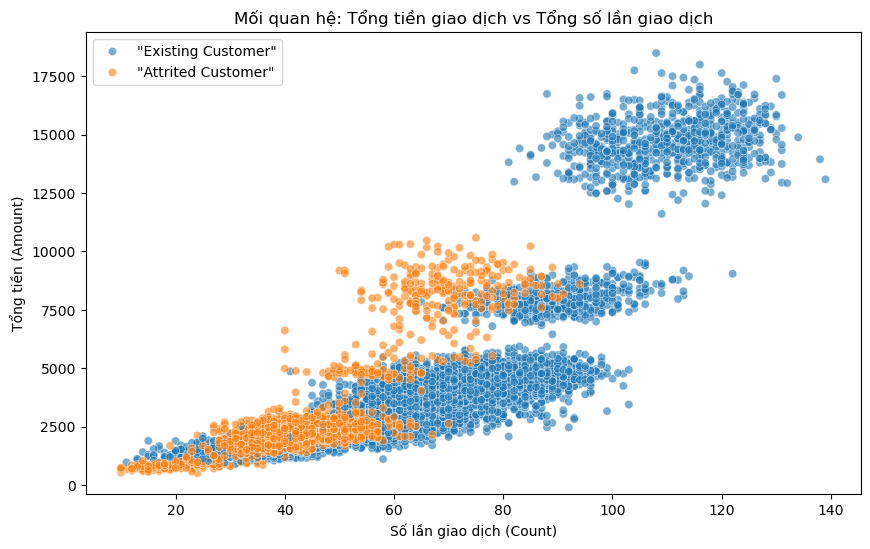

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['Total_Trans_Ct'], y=data['Total_Trans_Amt'],
                hue=data['Attrition_Flag'], alpha=0.6)
plt.title('Mối quan hệ: Tổng tiền giao dịch vs Tổng số lần giao dịch')
plt.xlabel('Số lần giao dịch (Count)')
plt.ylabel('Tổng tiền (Amount)')
plt.show()

**Phân tích tỉ lệ rời bỏ theo số tiền giao dịch và tần suất giao dịch:**
1. Đa số người dùng ở lại có tần suất giao dịch trung bình cao, có một nhóm giao dịch với tần suất cao và số tiền giao dịch lớn
2. Đa số người dùng rời đi có tần suất giao dịch trung bình thấp, số tiền giao dịch cũng nằm ở mức trung bình thấp. **Điều này chứng tỏ rằng nhóm người dùng giao dịch ít lần và số tiền giao dịch thấp có nguy cơ rời đi tương đối cao**



## **Mục tiêu dự đoán:** 
*Liệu chỉ dựa vào các yếu tố có trong dataset mà không phân tích cụ thể có thể dự đoán được một người dùng có ý định rời đi khỏi dịch vụ tín dụng hay không*

--> Do vậy, ta sẽ tiến hành tiền xử lý và xây dựng một mô hình phân loại người dùng xem họ sẽ rời đi hay không